AYEBIE GRAM MESCHAC

2000250045

ASSIGNMENT_Final (data_base merge)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Question 1

In [2]:
# Load population dataset
population = pd.read_csv("C:/Users/Meschac/Desktop/ASSIGNMENT/population.csv")

In [3]:
# Display of population using head for the first 5 observations of the dataset
population.head()

,NAME,POPESTIMATE
0,United States,331501080
1,Northeast Region,57525633
2,Midwest Region,68935174
3,South Region,126409007
4,West Region,78631266


In [4]:
population.shape

(57, 2)

In [5]:
# Variable
population.columns

Index(['NAME', 'POPESTIMATE'], dtype='object')

The dataset contained 2 variables such as : NAME and POPESTIMATE

We also have a datset of 57 observations

In [7]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         57 non-null     object
 1   POPESTIMATE  57 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ KB


In [8]:
population.isnull().sum()

NAME           0
POPESTIMATE    0
dtype: int64

In [9]:
# Filter for rows where 'NAME' contains 'Region'
regions_df = population[population['NAME'].str.contains('Region')]

# Display the list of region names
print("List of Regions:")
print(regions_df['NAME'].tolist())

List of Regions:
['Northeast Region', 'Midwest Region', 'South Region', 'West Region']


In [10]:
# Display all unique values in the 'NAME' column
print("All unique values in the 'NAME' column:")
print(population['NAME'].unique())

All unique values in the 'NAME' column:
['United States' 'Northeast Region' 'Midwest Region' 'South Region'
 'West Region' 'Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California'
 'Colorado' 'Connecticut' 'Delaware' 'District of Columbia' 'Florida'
 'Georgia' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas'
 'Kentucky' 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan'
 'Minnesota' 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'North Carolina'
 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont'
 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming'
 'Puerto Rico']


The datset contained no missing values

This data represent the population estimate in United State.
These are the 50 United States, plus the two entities often associated with them for statistical purposes: the 50 States (e.g., 'California', 'Texas', 'New York', 'Florida', etc.) and the 'District of Columbia' (Washington D.C., the federal capital).

Puerto Rico one of the city is not an incorporated U.S. territory. It is an unincorporated, organized territory of the United States

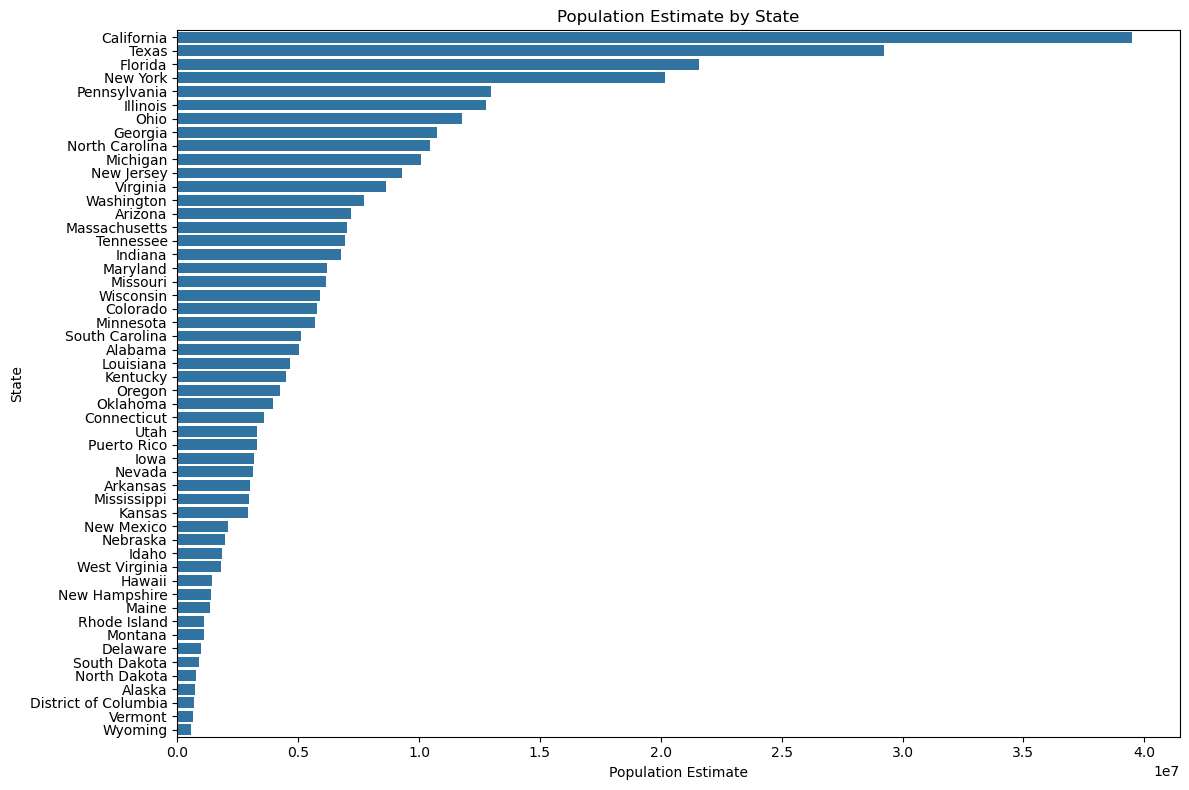

In [11]:
# Filter out regional data, United States, and Puerto Rico
filtered_population = population[~population['NAME'].str.contains('Region')]
filtered_population = filtered_population[filtered_population['NAME'] != 'United States']

# Sort the data by population estimate in descending order for better visualization
filtered_population = filtered_population.sort_values('POPESTIMATE', ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='POPESTIMATE', y='NAME', data=filtered_population)
plt.title('Population Estimate by State')
plt.xlabel('Population Estimate')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In United State, Califormia is the state with the bigest population estimate follow by Texas , Florida and New York. Also The District of Columbia, which represents Washington, the federal capital of the United States, has a very low estimated population and therefore ranks at the bottom of the list.
The state with te smallest population estimate is Wyoming

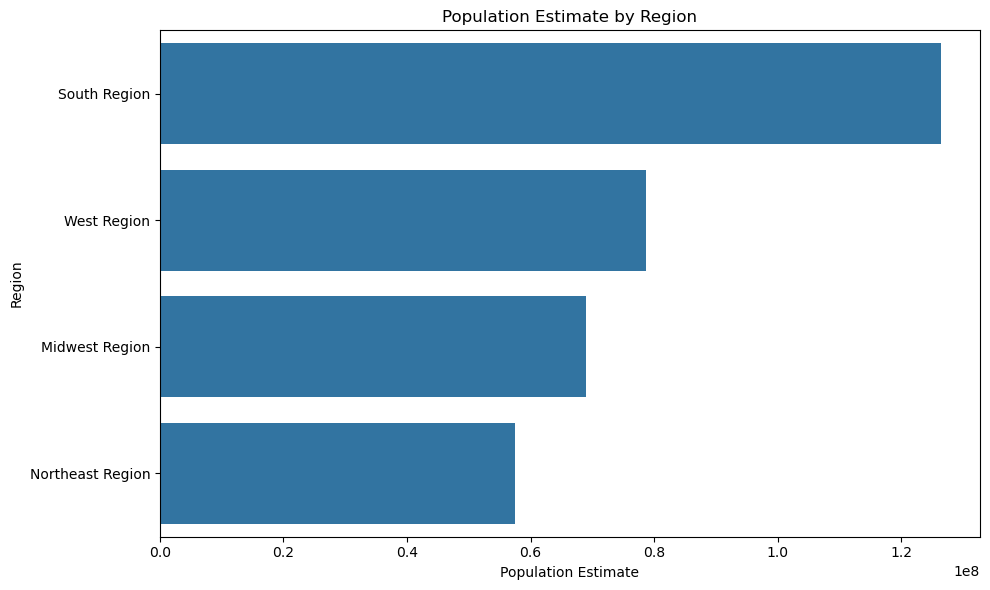

In [12]:
# Filter for rows where 'NAME' contains 'Region'
regions_df = population[population['NAME'].str.contains('Region')]

# Sort the data by population estimate in descending order
regions_df = regions_df.sort_values('POPESTIMATE', ascending=False)

# Create a bar plot for regions
plt.figure(figsize=(10, 6))
sns.barplot(x='POPESTIMATE', y='NAME', data=regions_df)
plt.title('Population Estimate by Region')
plt.xlabel('Population Estimate')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

Using the Region we can see well that teh South region where is California with the bigest population in United State is the first follow by the West Region , the Mdwest Region and the Northeast Region

Question 2

In [13]:
homicides = pd.read_csv("C:/Users/Meschac/Desktop/ASSIGNMENT/homicides.csv")

In [14]:
homicides.head()

,STATE,DEATHS
0,AL,654
1,AK,55
2,AZ,525
3,AR,371
4,CA,2368


In [15]:
homicides.shape

(50, 2)

In [17]:
homicides.describe()

,DEATHS
count,50.000000
mean,487.780000
std,531.595645
min,14.000000
25%,88.250000
50%,335.000000
75%,728.250000
max,2368.000000


In [ ]:
En moyenne 487.78 personnes meurt au Etats Unis 

question 3

In [48]:
names = pd.read_csv("C:/Users/Meschac/Desktop/ASSIGNMENT/state_codes.csv")

In [49]:
names.head()

,State,Code
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


Question 4

In [50]:
names_homicides = pd.merge(homicides, names, left_on='STATE', right_on='Code', how='left')

Question 5

In [51]:
names_homicides.head()

,STATE,DEATHS,State,Code
0,AL,654,Alabama,AL
1,AK,55,Alaska,AK
2,AZ,525,Arizona,AZ
3,AR,371,Arkansas,AR
4,CA,2368,California,CA


Question 6

In [52]:
names_homicides2 = names_homicides.drop('Code', axis=1)

In [53]:
names_homicides2.head()

,STATE,DEATHS,State
0,AL,654,Alabama
1,AK,55,Alaska
2,AZ,525,Arizona
3,AR,371,Arkansas
4,CA,2368,California


Question 7

In [54]:
names_homicides = names_homicides2.rename(columns={'DEATHS': 'homicides', 'State': 'state'})

In [55]:
names_homicides

,STATE,homicides,state
0,AL,654,Alabama
1,AK,55,Alaska
2,AZ,525,Arizona
3,AR,371,Arkansas
4,CA,2368,California
5,CO,336,Colorado
6,CT,152,Connecticut
7,DE,86,Delaware
8,FL,1530,Florida
9,GA,1093,Georgia


Question 8

In [56]:
combined = pd.merge(names_homicides, population, left_on='state', right_on='NAME', how='outer')

In [57]:
combined.head(10)

,STATE,homicides,state,NAME,POPESTIMATE
0,AL,654.0,Alabama,Alabama,5024803
1,AK,55.0,Alaska,Alaska,732441
2,AZ,525.0,Arizona,Arizona,7177986
3,AR,371.0,Arkansas,Arkansas,3012232
4,CA,2368.0,California,California,39499738
5,CO,336.0,Colorado,Colorado,5784308
6,CT,152.0,Connecticut,Connecticut,3600260
7,DE,86.0,Delaware,Delaware,991886
8,NaN,NaN,NaN,District of Columbia,690093
9,FL,1530.0,Florida,Florida,21569932


Question 9

In [58]:
# Show rows with any NaN values
rows_with_nan = combined[combined.isnull().any(axis=1)]
display(rows_with_nan)

,STATE,homicides,state,NAME,POPESTIMATE
8,NaN,NaN,NaN,District of Columbia,690093
23,NaN,NaN,NaN,Midwest Region,68935174
36,NaN,NaN,NaN,Northeast Region,57525633
41,NaN,NaN,NaN,Puerto Rico,3281538
45,NaN,NaN,NaN,South Region,126409007
48,NaN,NaN,NaN,United States,331501080
53,NaN,NaN,NaN,West Region,78631266


In [59]:
combined.shape

(57, 5)

In [60]:
combined.isna().sum()

STATE          7
homicides      7
state          7
NAME           0
POPESTIMATE    0
dtype: int64

After the merge we have 7 missing values from the columns STATE,homicides and state 

Question 10

In [61]:
combined = combined.dropna(axis=0)

In [62]:
combined.head()

,STATE,homicides,state,NAME,POPESTIMATE
0,AL,654.0,Alabama,Alabama,5024803
1,AK,55.0,Alaska,Alaska,732441
2,AZ,525.0,Arizona,Arizona,7177986
3,AR,371.0,Arkansas,Arkansas,3012232
4,CA,2368.0,California,California,39499738


In [63]:
combined.isna().sum()

STATE          0
homicides      0
state          0
NAME           0
POPESTIMATE    0
dtype: int64

In [64]:
combined.shape

(50, 5)

Question 11

In [65]:
combined = combined.drop('NAME', axis=1)

In [66]:
combined.head()

,STATE,homicides,state,POPESTIMATE
0,AL,654.0,Alabama,5024803
1,AK,55.0,Alaska,732441
2,AZ,525.0,Arizona,7177986
3,AR,371.0,Arkansas,3012232
4,CA,2368.0,California,39499738


In [67]:
combined.shape

(50, 4)

In [68]:
combined.columns

Index(['STATE', 'homicides', 'state', 'POPESTIMATE'], dtype='object')

Question 12

In [69]:
combined = combined.rename(columns={'POPESTIMATE':'population'})

In [70]:
combined.head()

,STATE,homicides,state,population
0,AL,654.0,Alabama,5024803
1,AK,55.0,Alaska,732441
2,AZ,525.0,Arizona,7177986
3,AR,371.0,Arkansas,3012232
4,CA,2368.0,California,39499738


In [71]:
combined['homicide_rate'] = (combined['homicides'] / combined['population']) * 100000

In [72]:
combined.head()

,STATE,homicides,state,population,homicide_rate
0,AL,654.0,Alabama,5024803,13.015436
1,AK,55.0,Alaska,732441,7.509137
2,AZ,525.0,Arizona,7177986,7.314029
3,AR,371.0,Arkansas,3012232,12.316448
4,CA,2368.0,California,39499738,5.994976


In [73]:
sorted_combined = combined.sort_values('homicide_rate', ascending=False)

In [74]:
sorted_combined.head()

,STATE,homicides,state,population,homicide_rate
25,MS,576.0,Mississippi,2956870,19.480058
18,LA,873.0,Louisiana,4651203,18.769338
26,MO,803.0,Missouri,6154481,13.047404
0,AL,654.0,Alabama,5024803,13.015436
3,AR,371.0,Arkansas,3012232,12.316448


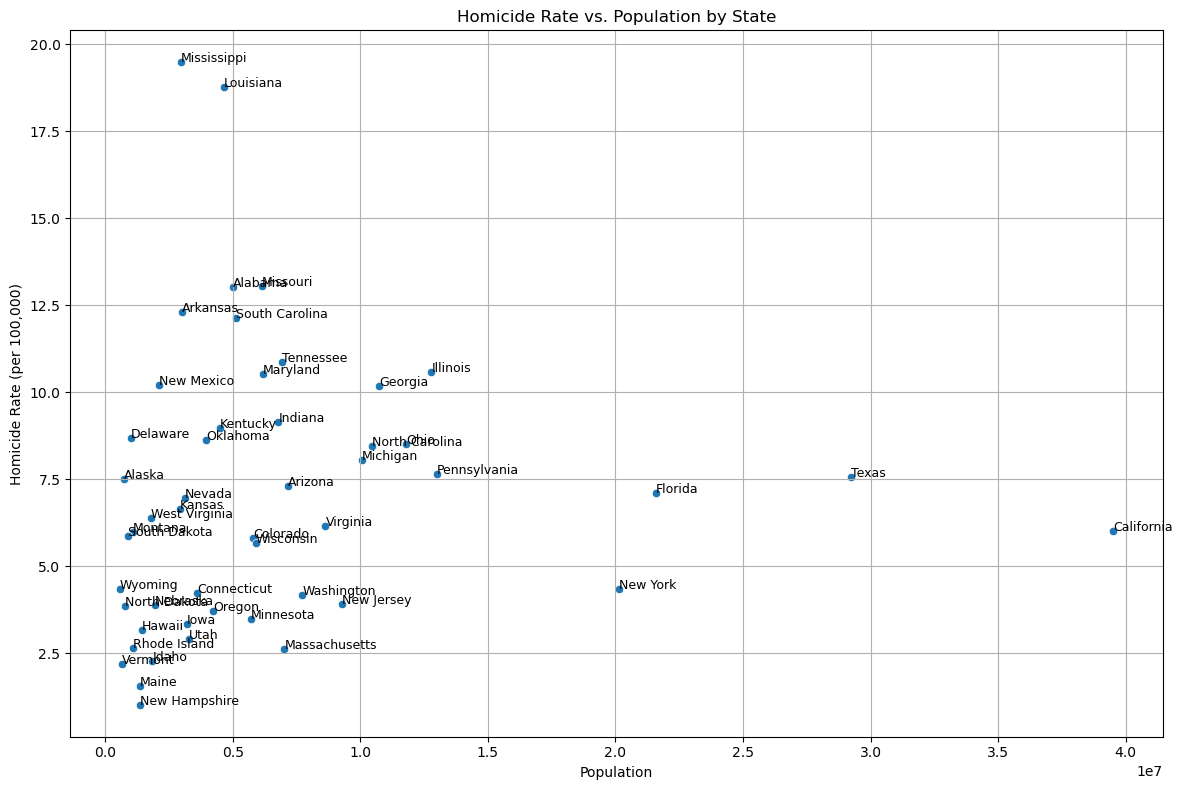

In [76]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='population', y='homicide_rate', data=combined)

# Add state labels to the points
for index, row in combined.iterrows():
    plt.text(row['population'], row['homicide_rate'], row['state'], fontsize=9)

plt.title('Homicide Rate vs. Population by State')
plt.xlabel('Population')
plt.ylabel('Homicide Rate (per 100,000)')
plt.grid(True)
plt.tight_layout()
plt.show()

This graph compares the homicide rate (per 100,000 inhabitants) on the vertical axis (Y) and the total population of each U.S. state on the horizontal axis (X).

The points are widely spread out on the horizontal axis, and no clear trend (neither positive nor negative) emerges. A linear regression line would have a slope close to zero. This indicates that whether a state is densely or sparsely populated is not a determining factor in its homicide rate. The factors driving homicides are therefore likely socioeconomic and cultural variables, rather than raw demographics.

There is no clear correlation between population and homicide rate. Densely populated states (such as California, Texas, Florida, and New York) do not necessarily have the highest homicide rates, but conversely, some sparsely populated states (Mississippi, Louisiana, and Missouri) have very high rates.

It also exhibits a wide dispersion of homicide rates.

Indeed, the rate varies from approximately 1 to nearly 20 homicides per 100,000 inhabitants, demonstrating significant regional differences.

Extreme states such as Mississippi (approximately 20) and Louisiana (approximately 19) are positive outliers: very high homicide rates despite a relatively small population. Furthermore, California (approximately 6) and New York (approximately 4.5) are more populated but have moderate homicide rates. Finally, New Hampshire, Maine, and Vermont are the safest states, with rates below 2.

Regarding the concentration of the data points, the majority of states have rates between 3 and 10 homicides per 100,000 inhabitants, with a population of less than 10 million.

All of these analyses imply that if we were to calculate the correlation coefficient (r) between population and homicide rate, it would likely be close to 0, indicating no strong linear relationship.

In contrast, clustering (K-Means, for example) could reveal distinct groups:

- Sparsely populated states with low homicide rates (Northeast)
- Sparsely populated but violent states (South)
- Densely populated and moderately violent states (large metropolitan areas)

Southern states (Mississippi, Louisiana, Alabama, Arkansas) show high rates, often linked to:

- Economic Inequality and Poverty: Historically, this region has exhibited higher levels of income inequality and poverty than other American regions. Economic insecurity is a factor often correlated with violent crime.

- Gun Culture: Gun laws in many Southern states are among the least restrictive in the United States, which could increase the lethality of conflicts.

- Underinvestment in Social Services: Reduced investment in education, mental health programs, and social reintegration services can exacerbate violence.

- Public Health Issues: High rates of substance abuse and untreated mental health problems can contribute to violence.

Northeastern and West Coast states often benefit from:
- higher levels of education and income,
- more effective security and prevention policies.

Regional socioeconomic factors appear to play a far more significant role than population size.

In general, this graph shows that a large population does not necessarily mean a high homicide rate.
